# **Creating and Training an AI Model**
## **Step 1: Load the MNIST Dataset**
### Run the following code to load and preprocess the MNIST dataset:

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


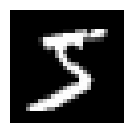

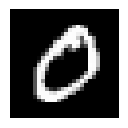

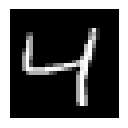

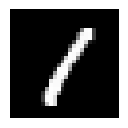

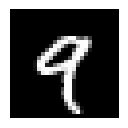

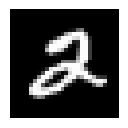

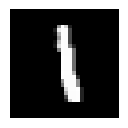

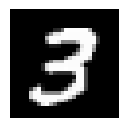

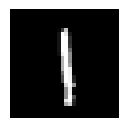

In [3]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Normalize data (scale pixel values between 0 and 1)
x_train, x_test = x_train / 255.0, x_test / 255.0
# Show sample images
plt.figure(figsize=(5,5))
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.imshow(x_train[i], cmap="gray")
  plt.axis('off')
  plt.show()

# **Step 2: Define and Train a Neural Network**
### Create a simple feedforward neural network using Keras:

In [4]:
# Define model architecture
model = tf.keras.models.Sequential([
                                    # Input layer (flatten 28x28 pixels)
                                    tf.keras.layers.Flatten(input_shape=(28,28)),
                                    # Hidden layer
                                    tf.keras.layers.Dense(128, activation='relu'),
                                    # Output layer (10 classes)
                                    tf.keras.layers.Dense(10, activation='softmax')
                                    ])
# Compile model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Train model
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))
# Save trained model
model.save("mnist_model.h5")
print("Model training complete and saved as mnist_model.h5")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8783 - loss: 0.4293 - val_accuracy: 0.9511 - val_loss: 0.1569
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9637 - loss: 0.1241 - val_accuracy: 0.9684 - val_loss: 0.1035
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9773 - loss: 0.0778 - val_accuracy: 0.9738 - val_loss: 0.0857
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9814 - loss: 0.0618 - val_accuracy: 0.9760 - val_loss: 0.0759
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9870 - loss: 0.0437 - val_accuracy: 0.9745 - val_loss: 0.0826


Model training complete and saved as mnist_model.h5


# **Converting and Saving the Model**
## **Step 3: Convert the Model to TensorFlow Lite Format**
### Now, we will convert the trained model to TensorFlow Lite so it can run efficiently on smaller devices.

In [5]:
# Load trained model
model = tf.keras.models.load_model("mnist_model.h5")

# Convert to TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_model = converter.convert() # Save the converted model
with open("mnist_model.tflite", "wb") as f:
  f.write(tflite_model)
  print("Model successfully converted and saved as mnist_model.tflite")

Saved artifact at '/tmp/tmp7alk07wj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  132283042478224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132283042477456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132283042477840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132283042473424: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model successfully converted and saved as mnist_model.tflite


# **Loading and Running Inference with TensorFlow Lite**
## **Step 4: Load the Converted Model Using TensorFlow Lite Interpreter**
### We will now load the .tflite model and test it on sample data.

In [6]:
# Load TensorFlow Lite model
interpreter = tf.lite.Interpreter(model_path="mnist_model.tflite")
interpreter.allocate_tensors()
# Get input and output tensor details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
print("Input Details:", input_details)
print("Output Details:", output_details)

Input Details: [{'name': 'serving_default_input_layer:0', 'index': 0, 'shape': array([ 1, 28, 28], dtype=int32), 'shape_signature': array([-1, 28, 28], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output Details: [{'name': 'StatefulPartitionedCall_1:0', 'index': 9, 'shape': array([ 1, 10], dtype=int32), 'shape_signature': array([-1, 10], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


# **Step 5: Perform Inference with TensorFlow Lite**
### We will now run inference on a test image using the TFLite interpreter.

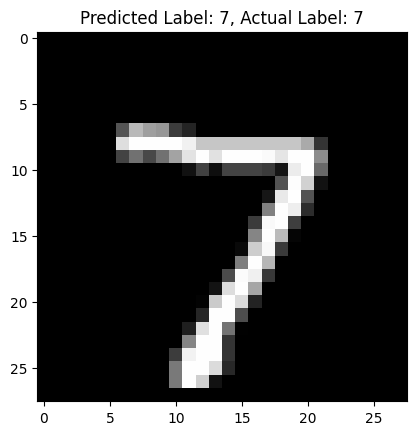

In [7]:
# Select a test image
# Ensure data type matches model input
test_image = x_test[0].astype(np.float32)

# Reshape for model input
test_image = np.expand_dims(test_image, axis=0)

# Set the input tensor
interpreter.set_tensor(input_details[0]['index'], test_image)

# Run inference
interpreter.invoke()

# Get the prediction
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_label = np.argmax(output_data)

# Display the image and prediction
plt.imshow(x_test[0], cmap="gray")
plt.title(f"Predicted Label: {predicted_label}, Actual Label: {y_test[0]}")
plt.show()